#Lab Assignment 1: Linear Regression with Gradient Descent

id - 202301122
name - Kosha Dalsaniya

# 1.1 First Subtask: Dataset Preparation


In [ ]:
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
import numpy as np

In [ ]:
# Load dataset
boston = fetch_openml(name="boston", version=1, as_frame=True)
df = boston.frame

# Convert CHAS and RAD to float
df["CHAS"] = df["CHAS"].astype(float)
df["RAD"] = df["RAD"].astype(float)



# removes MEDV, gets feature names, converts them to python list
X_feature_names = df.drop(columns="MEDV").columns.to_list()



# split the features and regression labels
X = df.drop(columns="MEDV").to_numpy() # all columns except MEDV (featue matrix)
y = df["MEDV"].to_numpy()  # Median value of homes (in $1000s) (target)

# convert shape from (M,) to (M,1)
y=np.expand_dims(y, axis=1)

In [ ]:
print(X.shape)
print(y.shape)
print(X[1])

(506, 13)
(506, 1)
[2.7310e-02 0.0000e+00 7.0700e+00 0.0000e+00 4.6900e-01 6.4210e+00
 7.8900e+01 4.9671e+00 2.0000e+00 2.4200e+02 1.7800e+01 3.9690e+02
 9.1400e+00]


In [ ]:
#### Random Data Splitting ###
# 1) Split 80% train+val, 20% test
X_train_val, X_test, y_train_val, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 2) Further split  train+val into 75% train, 25% val
X_train, X_val, y_train, y_val = train_test_split(X_train_val, y_train_val, test_size=0.25, random_state=84)

# Check sizes
print("Train:", X_train.shape, y_train.shape)
print("Validation:", X_val.shape, y_val.shape)
print("Test:", X_test.shape, y_test.shape)


Train: (303, 13) (303, 1)
Validation: (101, 13) (101, 1)
Test: (102, 13) (102, 1)


In [ ]:
##### Feature Normalization: Training Set ####
# In training dataset, (1) subtract mean of each dimension  (2) divide by standard deviation of each dimension
#apply standardization (z-score scalling)
trn_mu=np.mean(X_train, axis=0, keepdims=True) # 1,D keepdims for (1, 13), without it it would be(,13)
print('trn_mu shape: '+str(trn_mu.shape))

trn_std=np.std(X_train, axis=0, keepdims=True) # 1,D
print('trn_std shape: '+str(trn_std.shape))


X_trn_nrm=(X_train-trn_mu)/(trn_std+ 1e-5)  # shape broadcasting, Normalize X


trn_y_mu=np.mean(y_train, axis=0, keepdims=True) # 1,1
print('trn_y_mu shape: '+str(trn_y_mu.shape))

trn_y_std=np.std(y_train, axis=0, keepdims=True) # 1,1
print('trn_y_std shape: '+str(trn_y_std.shape))

y_trn_nrm=(y_train-trn_y_mu)/(trn_y_std+1e-5)


trn_mu shape: (1, 13)
trn_std shape: (1, 13)
trn_y_mu shape: (1, 1)
trn_y_std shape: (1, 1)


In [ ]:
print(y_trn_nrm)


[[ 7.56103802e-01]
 [-1.30680145e+00]
 [-5.30553598e-01]
 [-2.96615889e-01]
 [-8.70826630e-01]
 [-1.54073916e+00]
 [-9.45787768e-02]
 [ 1.60678638e+00]
 [-6.47522453e-01]
 [-3.60417083e-01]
 [ 2.23416478e+00]
 [-5.73087727e-01]
 [ 2.03160126e-01]
 [-6.04988324e-01]
 [ 3.83930174e-01]
 [-5.30553598e-01]
 [ 1.81893061e-01]
 [-3.07249422e-01]
 [ 5.96600818e-01]
 [-7.21957179e-01]
 [ 2.25543185e+00]
 [-7.96391904e-01]
 [ 9.79407979e-01]
 [-1.54073916e+00]
 [ 1.45791693e+00]
 [ 8.61912712e-02]
 [-1.65770802e+00]
 [ 8.41172060e-01]
 [-6.04988324e-01]
 [-2.01440512e-02]
 [-4.77385937e-01]
 [ 2.40430130e+00]
 [-1.00906255e+00]
 [-7.00690114e-01]
 [ 2.35060722e-01]
 [-1.51947210e+00]
 [-5.20446479e-02]
 [-9.55894888e-01]
 [ 3.30236100e-02]
 [-9.51051893e-03]
 [-3.92317679e-01]
 [-6.26781801e-02]
 [ 9.36873850e-01]
 [ 3.30236100e-02]
 [-9.98429017e-01]
 [-1.15845841e-01]
 [-3.71050615e-01]
 [-2.54081760e-01]
 [ 6.28501415e-01]
 [-1.90280567e-01]
 [-7.85758372e-01]
 [ 1.07458336e-01]
 [ 1.1756545

In [ ]:
######## Feature Normalization: Val and Test Set (Use training sets mean and std dev.) ###########
X_val_nrm=(X_val-trn_mu)/(trn_std+ 1e-5)
y_val_nrm=(y_val-trn_y_mu)/(trn_y_std+1e-5)

X_tst_nrm=(X_test-trn_mu)/(trn_std+ 1e-5)
y_tst_nrm=(y_test-trn_y_mu)/(trn_y_std+1e-5)

In [ ]:
# Feature Augmentation: Append a 1 to the first dimension of the feature to account for bias
X_trn_nrm=np.concatenate((np.ones((X_trn_nrm.shape[0],1)),X_trn_nrm), axis=1) # alternatively use np.hstack, add the 1 initially y=theta0 + theta1x1+....
X_val_nrm = np.concatenate((np.ones((X_val_nrm.shape[0],1)), X_val_nrm), axis=1)
X_tst_nrm = np.concatenate((np.ones((X_tst_nrm.shape[0],1)), X_tst_nrm), axis=1)


# 1.2 Second Subtask: Implement Gradient Descent


In [ ]:
#find the batches for computation
def get_sample(X, y, batch_sz):
    idx = np.random.permutation(X.shape[0])  # shuffle once
    for start in range(0, X.shape[0], batch_sz): #batch size=32 [0,32,64,....]
        batch_idx = idx[start:start+batch_sz] #select 32 random samples
        yield X[batch_idx], y[batch_idx] # instead of storing the batches in memory, it generates them one by one


In [ ]:
def get_gradient(X, y, theta):
    m = X.shape[0]
    grad = (1/m) * X.T @ (X @ theta - y)
    return grad

In [ ]:
def compute_mse_loss(X, y, theta):
    m = X.shape[0]
    err = X @ theta - y
    mse_loss = (1/(2*m)) * np.sum(err**2)
    return mse_loss

In [ ]:
def gradient_descent(X_trn,y_trn, X_val, y_val, lr=0.01, batch_sz=32, max_epochs=200, patience=50):

    nupdates_per_epoch=X_trn.shape[0]//batch_sz
    # Our learnable parameter
    theta=np.zeros((X_trn.shape[1],1))
    best_theta=theta.copy()
    best_loss=99999.99

    early_stop_counter=0


    log_trn_loss=[]
    log_val_loss=[]
    for epochs in range(0, max_epochs):
        for batch_X, batch_y in get_sample(X_trn, y_trn, batch_sz):
            # Update theta with gradient descent
            theta=theta-lr*get_gradient(batch_X, batch_y, theta)


        # end of an epoch
        trn_loss=compute_mse_loss(X_trn, y_trn, theta)
        val_loss=compute_mse_loss(X_val, y_val, theta)

        #print(f"Epoch {epochs} | Train: {trn_loss:.4f} | Val: {val_loss:.4f}")

        log_trn_loss.append(trn_loss)
        log_val_loss.append(val_loss)

        # save the best performing weight on the validation set
        if val_loss< best_loss:
            best_loss=val_loss
            best_theta=theta.copy()
            early_stop_counter=0 # reset
        else:
            early_stop_counter=early_stop_counter+1

        # Check for early stopping
        if early_stop_counter>=patience:
            print('Early Stopping !')
            break


    log_trn_loss=np.array(log_trn_loss)
    log_val_loss=np.array(log_val_loss)
    return best_theta, log_trn_loss, log_val_loss

In [ ]:
best_theta, log_trn_loss, log_val_loss=gradient_descent(X_trn_nrm,y_trn_nrm, X_val_nrm, y_val_nrm, lr=0.01, batch_sz=64, max_epochs=200, patience=50)

Early Stopping !


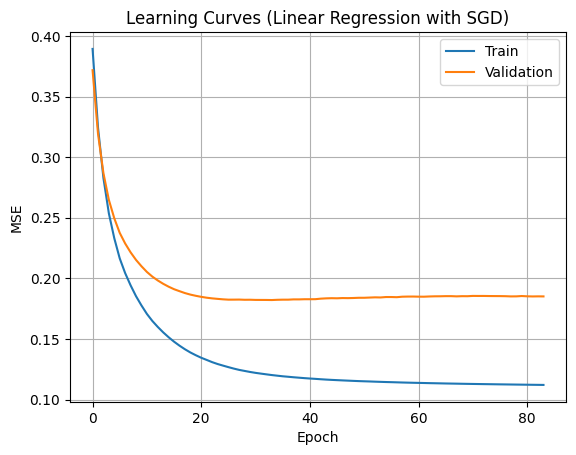

In [ ]:
import matplotlib.pyplot as plt
plt.figure()
plt.plot(log_trn_loss, label="Train")
plt.plot(log_val_loss, label="Validation")
plt.xlabel("Epoch")
plt.ylabel("MSE")
plt.title("Learning Curves (Linear Regression with SGD)")
plt.grid(True)
plt.legend()
plt.show()

# 1.3 effect of learning rate


In [ ]:
learning_rates = [1e-5, 1e-4, 1e-3, 1e-2, 1e-1, 1.0, 10.0]
results={}
best_lr = None
best_val = float("inf")

for lr in learning_rates:
    print(f"\nTraining with lr = {lr}")

    theta, trn_log, val_log = gradient_descent(
        X_trn_nrm, y_trn_nrm,
        X_val_nrm, y_val_nrm,
        lr=lr,
        batch_sz=128,
        max_epochs=200,
        patience=50
    )

    results[lr] = (trn_log, val_log)

    best_val_lr = np.min(val_log)   # ⭐ FIX

    if best_val_lr < best_val:
        best_val = best_val_lr
        best_lr = lr


print(f"Best learning rate: {best_lr}")
print(f"Best validation loss: {best_val:.6f}")


Training with lr = 1e-05

Training with lr = 0.0001

Training with lr = 0.001

Training with lr = 0.01
Early Stopping !

Training with lr = 0.1
Early Stopping !

Training with lr = 1.0
Early Stopping !

Training with lr = 10.0
Early Stopping !
Best learning rate: 0.1
Best validation loss: 0.180772


/tmp/ipython-input-543305728.py:4: RuntimeWarning: overflow encountered in square
  mse_loss = (1/(2*m)) * np.sum(err**2)


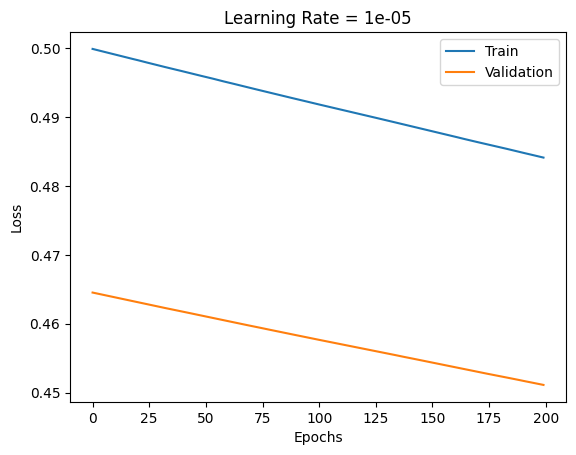

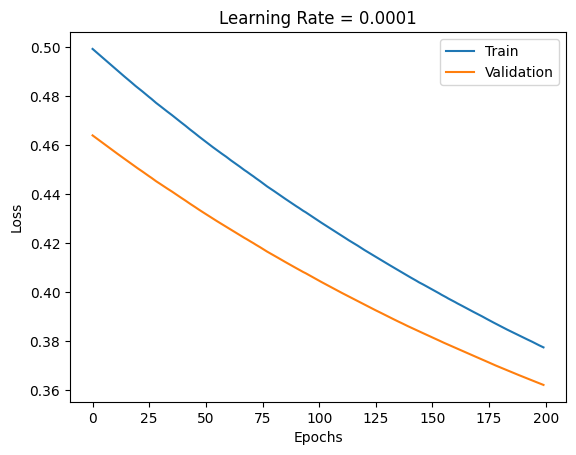

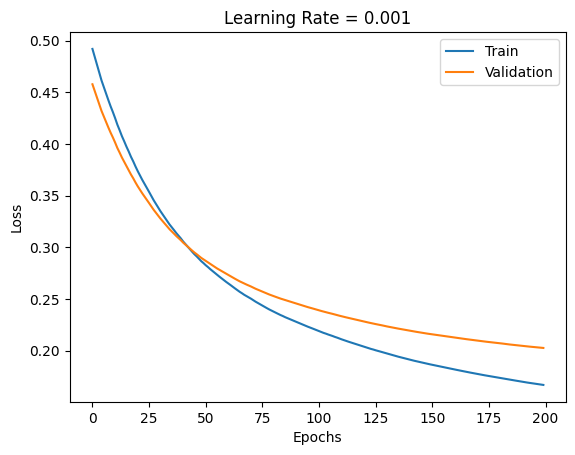

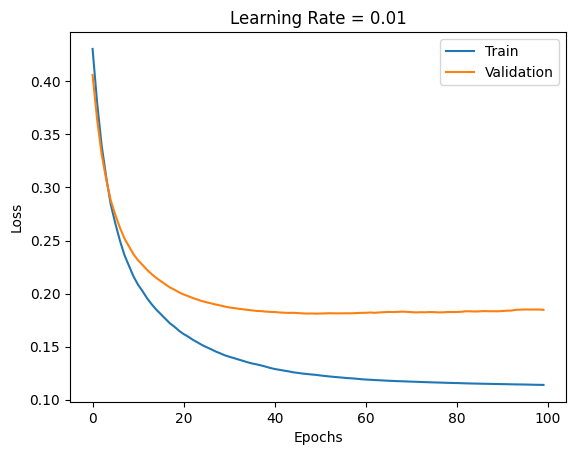

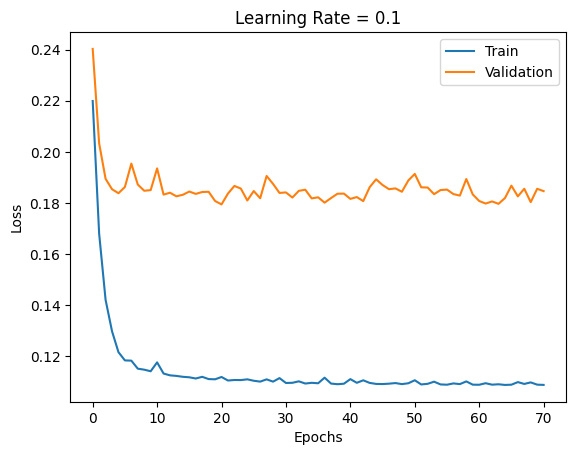

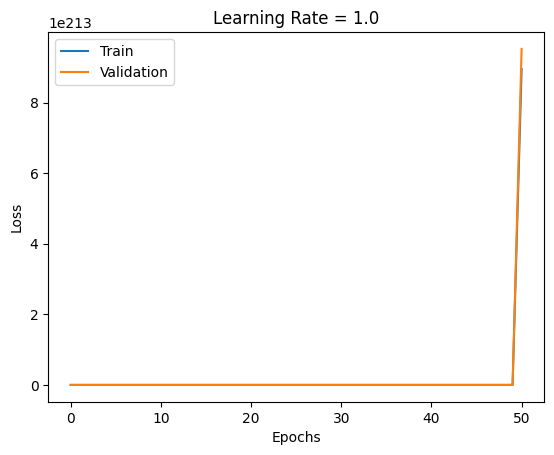

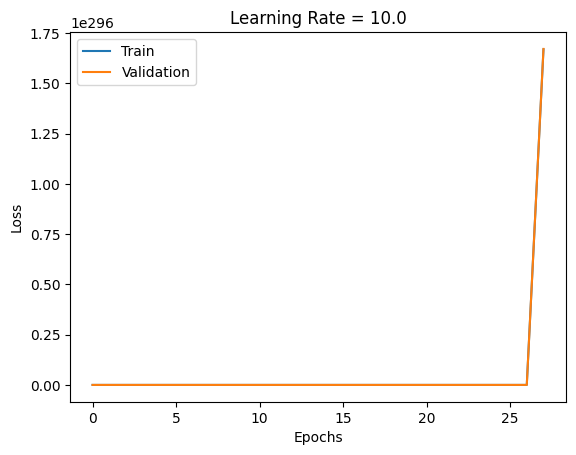

In [ ]:
import matplotlib.pyplot as plt

for lr in learning_rates:
    trn_log, val_log = results[lr]

    plt.figure()   # new plot for each lr

    plt.plot(trn_log, label="Train")
    plt.plot(val_log, label="Validation")

    plt.title(f"Learning Rate = {lr}")
    plt.xlabel("Epochs")
    plt.ylabel("Loss")
    plt.legend()

    plt.show()


# 1.4 change of batch size


In [ ]:
batch_sizes = [1, 16, 32, 64, 128, 256, X_trn_nrm.shape[0]]

import time
import numpy as np

batch_results = {}
best_batch_size = None
best_val = float("inf")

for bs in batch_sizes:
    print(f"\nTraining with batch size = {bs}")

    start = time.time()

    theta, trn_log, val_log = gradient_descent(
        X_trn_nrm, y_trn_nrm,
        X_val_nrm, y_val_nrm,
        lr=best_lr,
        batch_sz=bs,
        max_epochs=200,
        patience=50
    )

    end = time.time()
    elapsed = end - start

    batch_results[bs] = (trn_log, val_log, elapsed)

    # ⭐ use BEST validation loss, not last
    best_val_bs = np.min(val_log)

    if best_val_bs < best_val:
        best_val = best_val_bs
        best_batch_size = bs


# ⭐ print winner AFTER loop
print("\n==============================")
print(f"Best batch size: {best_batch_size}")
print(f"Best validation loss: {best_val:.6f}")
print("==============================")



Training with batch size = 1
Early Stopping !

Training with batch size = 16
Early Stopping !

Training with batch size = 32
Early Stopping !

Training with batch size = 64
Early Stopping !

Training with batch size = 128
Early Stopping !

Training with batch size = 256
Early Stopping !

Training with batch size = 303
Early Stopping !

Best batch size: 16
Best validation loss: 0.173210


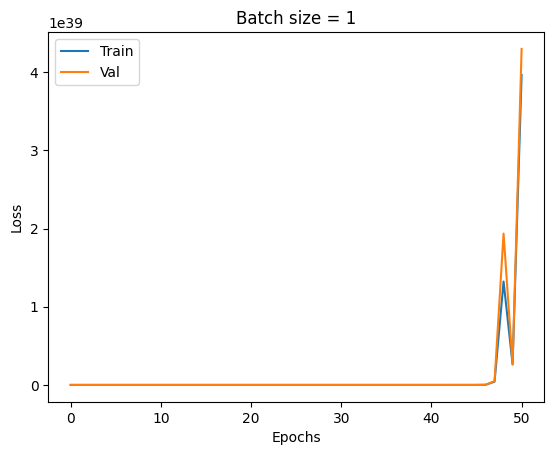

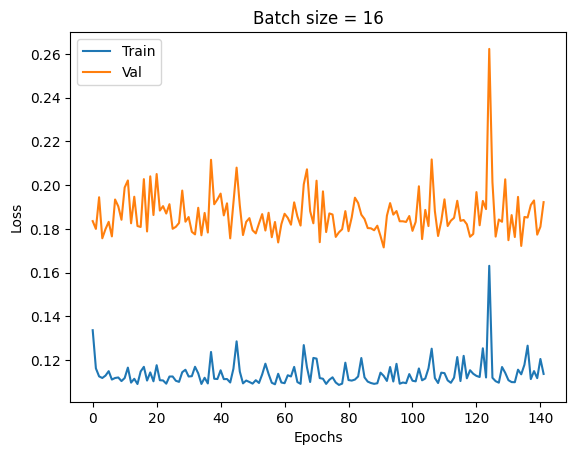

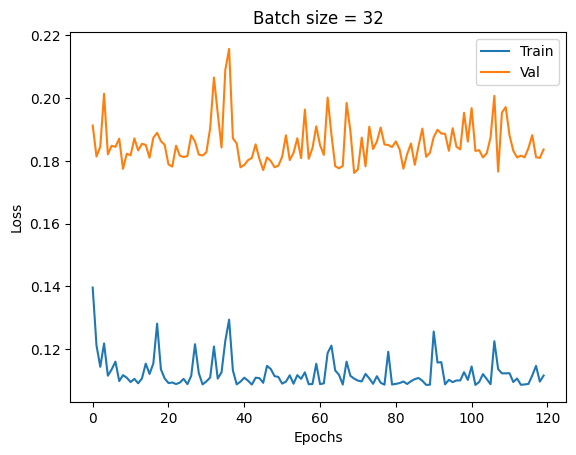

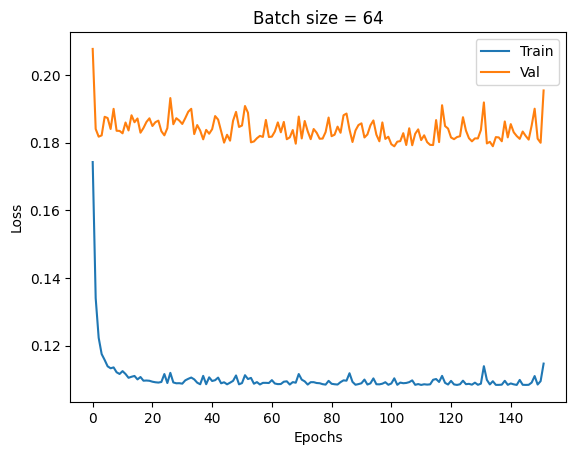

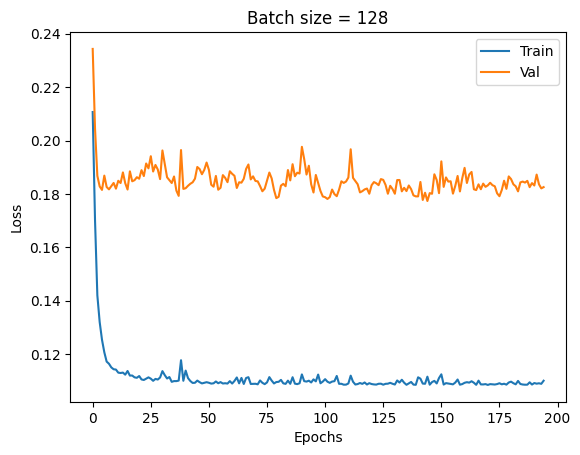

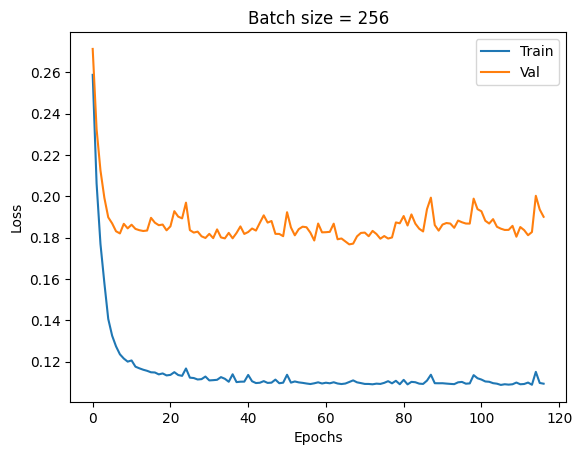

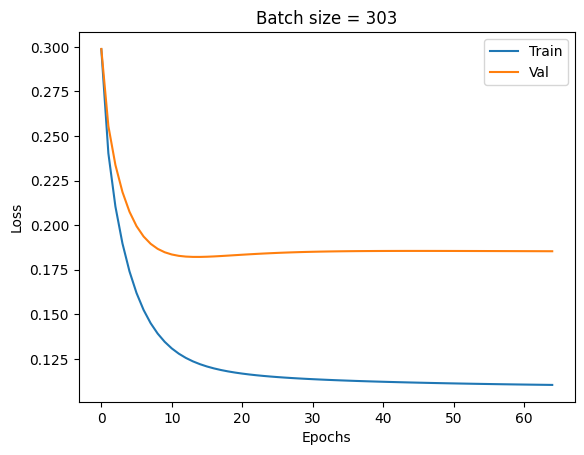

In [ ]:
import matplotlib.pyplot as plt

for bs in batch_sizes:
    trn_log, val_log, _ = batch_results[bs]

    plt.figure()
    plt.plot(trn_log, label="Train")
    plt.plot(val_log, label="Val")

    plt.title(f"Batch size = {bs}")
    plt.xlabel("Epochs")
    plt.ylabel("Loss")
    plt.legend()
    plt.show()


In [ ]:
for bs in batch_sizes:
    trn_log, val_log, t = batch_results[bs]
    print(f"batch={bs:4d} | final val loss={val_log[-1]:.4f} | epochs={len(val_log):3d} | time={t:.2f}s")


batch=   1 | final val loss=4296578579370504682897995064209439719424.0000 | epochs= 51 | time=0.31s
batch=  16 | final val loss=0.1922 | epochs=142 | time=0.07s
batch=  32 | final val loss=0.1836 | epochs=120 | time=0.04s
batch=  64 | final val loss=0.1954 | epochs=152 | time=0.03s
batch= 128 | final val loss=0.1826 | epochs=195 | time=0.03s
batch= 256 | final val loss=0.1901 | epochs=117 | time=0.02s
batch= 303 | final val loss=0.1853 | epochs= 65 | time=0.01s


# 1.5 Inference on unseen Test Set


In [ ]:
final_theta, trn_log, val_log = gradient_descent(
    X_trn_nrm, y_trn_nrm,
    X_val_nrm, y_val_nrm,
    lr=best_lr,
    batch_sz=best_batch_size,
    max_epochs=200,
    patience=50
)

train_loss = compute_mse_loss(X_trn_nrm, y_trn_nrm, final_theta)
val_loss   = compute_mse_loss(X_val_nrm, y_val_nrm, final_theta)
test_loss  = compute_mse_loss(X_tst_nrm, y_tst_nrm, final_theta)

print("\nFinal Performance")
print("Train MSE:", train_loss)
print("Val   MSE:", val_loss)
print("Test  MSE:", test_loss)


Early Stopping !

Final Performance
Train MSE: 0.11146044097746727
Val   MSE: 0.17508706455535966
Test  MSE: 0.15317274127958763
